# External Validation of Blood Transcriptomic Biomarkers for Parkinson’s Disease

## Training Dataset
**GEO accession:** GSE99039  
**Title:** *A blood-based gene signature characterizing Idiopathic Parkinson's disease*

## External Validation Dataset
**GEO accession:** GSE6613  
**Title:** *Parkinson's disease vs. controls, whole blood*

---

## Project Goal
The goal of this stage of the project is to evaluate whether a blood transcriptomic signature learned from the GSE99039 cohort can generalize to an independent external Parkinson’s disease dataset.

---

## Research Question
Can a machine learning model trained on one peripheral blood transcriptomic cohort accurately classify Parkinson’s disease patients in an independent external cohort generated in a different study?

---

## Objectives
- Load and preprocess the GSE99039 training dataset
- Load and preprocess the independent GSE6613 validation dataset
- Select comparable cohorts: idiopathic PD vs healthy controls
- Harmonize feature spaces between datasets using shared microarray probes
- Train machine learning models on GSE99039
- Perform strict external validation on GSE6613
- Evaluate generalization performance using ROC-AUC
- Assess the reproducibility of blood-based transcriptomic signatures across cohorts

---

## Motivation
A major challenge in transcriptomic biomarker research is whether predictive signals discovered in one cohort remain reproducible in independent patient populations.

External validation is therefore essential to evaluate the robustness, reproducibility, and potential translational relevance of blood-based molecular biomarkers for Parkinson’s disease.

---

## Workflow
1. Load and preprocess the GSE99039 training dataset  
2. Load and preprocess the GSE6613 external validation dataset  
3. Extract PD and healthy control samples  
4. Identify shared probe-level features between GPL570 and GPL96 platforms  
5. Train machine learning models on GSE99039  
6. Apply the trained model to GSE6613 without retraining  
7. Evaluate external ROC-AUC and classification performance  
8. Compare internal and external validation results  

---

## Important Methodological Notes
- GSE99039 is used exclusively for model training
- GSE6613 is used exclusively for external testing
- Feature harmonization is performed using intersecting probe IDs
- Scaling parameters are fitted only on the training cohort to avoid data leakage
- No information from the external cohort is used during model fitting

---

## Notes
This notebook represents the second stage of the project and focuses on external validation and reproducibility of transcriptomic biomarkers across independent Parkinson’s disease cohorts.

## Data Loading

In this stage, we load the GEO Series Matrix files for both the training cohort (GSE99039) and the independent external validation cohort (GSE6613).

The raw GEO metadata lines are excluded, and the expression matrices are imported into pandas DataFrames for downstream preprocessing.

In [1]:
# Imports
import pandas as pd
import numpy as np

### Load GSE99039 Training Dataset

The GSE99039 dataset serves as the primary training cohort for model development.

In [2]:
gse99039_path = "GSE99039_series_matrix.txt"

# Skip GEO metadata lines
gse99039_raw = pd.read_csv(
    gse99039_path,
    sep="\t",
    comment="!"
)

In [3]:
gse99039_raw.head()

,ID_REF,GSM2630758,GSM2630759,GSM2630760,GSM2630761,GSM2630762,GSM2630763,GSM2630764,GSM2630765,GSM2630766,...,GSM2631306,GSM2631307,GSM2631308,GSM2631309,GSM2631310,GSM2631311,GSM2631312,GSM2631313,GSM2631314,GSM2631315
0,1007_s_at,5.397,4.952,5.331,5.601,5.087,5.921,5.153,5.341,5.261,...,5.583,5.535,5.737,4.937,5.765,6.056,5.989,5.697,5.567,5.529
1,1053_at,5.199,5.198,4.970,5.816,5.443,5.430,5.243,5.167,5.324,...,5.775,5.004,5.672,5.415,5.195,5.282,5.228,5.528,5.706,5.078
2,117_at,8.327,8.589,8.629,9.628,9.449,9.230,9.269,9.095,9.184,...,8.426,7.061,6.771,8.691,7.073,7.325,8.567,6.844,8.511,8.458
3,121_at,7.042,6.935,7.701,6.909,7.284,7.153,6.850,7.541,6.918,...,7.192,7.326,7.319,6.702,7.747,7.712,7.743,7.468,7.526,7.673
4,1255_g_at,2.463,2.388,2.349,2.268,2.407,2.137,2.029,2.464,2.607,...,2.178,2.300,2.302,2.559,2.513,2.437,2.530,2.506,2.708,2.810


The dataset contains probe-level whole-blood gene expression measurements generated using the Affymetrix GPL570 microarray platform.

- Rows correspond to transcriptomic probes (`ID_REF`)
- Columns correspond to individual patient samples (`GSM` identifiers)
- Expression values are represented as normalized continuous microarray intensities

At this stage, the matrix is still organized in the original GEO format:
- probes × samples

The dataset will later be transposed to obtain a machine learning–compatible structure:
- samples × features

### Load GSE6613 External Validation Dataset

The GSE6613 dataset is used as an independent external cohort for evaluating model generalization.

In [4]:
gse6613_path = "GSE6613_series_matrix.txt"

# Skip GEO metadata lines
gse6613_raw = pd.read_csv(
    gse6613_path,
    sep="\t",
    comment="!"
)

In [5]:
gse6613_raw.head()

,ID_REF,GSM153404,GSM153405,GSM153406,GSM153407,GSM153408,GSM153409,GSM153410,GSM153411,GSM153412,...,GSM153499,GSM153500,GSM153501,GSM153502,GSM153503,GSM153504,GSM153505,GSM153506,GSM153507,GSM153508
0,1007_s_at,114.5,105.1,145.7,168.7,94.3,96.2,155.8,99.8,100.9,...,153.8,103.7,132.8,195.5,82.6,28.2,163.9,29.0,104.8,32.8
1,1053_at,64.4,58.4,52.5,45.4,51.3,50.7,42.2,6.7,44.0,...,44.0,70.5,61.9,52.2,61.2,67.6,101.9,46.8,74.9,78.1
2,117_at,206.3,179.8,192.0,263.6,211.9,149.5,157.3,216.6,230.5,...,268.9,48.6,193.6,132.5,165.5,146.0,291.4,246.2,251.2,210.0
3,121_at,507.0,497.8,346.3,430.7,485.5,437.6,424.1,678.7,434.1,...,403.6,559.1,569.7,532.8,525.7,603.9,479.7,271.9,506.1,270.4
4,1255_g_at,34.5,18.0,40.1,40.5,22.8,6.4,27.4,5.2,34.7,...,44.8,39.5,30.5,65.8,54.3,19.3,61.0,40.8,29.5,82.2


The external validation dataset was successfully loaded and will undergo preprocessing steps analogous to the training cohort.

## Data Preparation

We convert the datasets into a machine learning–ready format.

* Rows correspond to samples (patients)
* Columns correspond to gene expression values

We extract sample labels from the metadata and define a binary classification task:

* CONTROL → 0 (healthy individuals)
* IPD → 1 (idiopathic Parkinson’s disease)

Samples corresponding to other neurological conditions (e.g., MSA, PSP, etc.) are excluded to ensure a clean binary classification setup.

This results in a filtered dataset containing only PD patients and healthy controls.

### Important Methodological Consideration

Because the two datasets were generated using different Affymetrix microarray platforms (GPL570 vs GPL96), feature harmonization will later be performed using the intersection of shared probe identifiers across datasets.

In [6]:
gse99039_data = gse99039_raw.set_index("ID_REF")

# transpose → samples × probes
gse99039_X = gse99039_data.T

print(gse99039_X.shape)

(558, 54675)


In [7]:
gse99039_X.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM2630758,5.397,5.199,8.327,7.042,2.463,7.753,5.118,3.170,11.152,2.564,...,12.706,12.125,13.729,13.794,9.599,6.867,7.662,2.247,2.483,2.512
GSM2630759,4.952,5.198,8.589,6.935,2.388,8.210,5.107,2.677,11.029,2.603,...,11.955,11.334,13.432,13.374,9.313,5.786,7.116,2.155,2.445,2.331
GSM2630760,5.331,4.970,8.629,7.701,2.349,7.744,5.523,3.072,11.159,2.664,...,11.721,11.272,13.402,13.307,10.025,7.621,8.669,2.047,2.448,2.619
GSM2630761,5.601,5.816,9.628,6.909,2.268,7.670,4.579,3.025,10.528,2.551,...,11.549,10.737,13.180,13.179,8.817,6.220,7.168,2.055,2.356,2.409
GSM2630762,5.087,5.443,9.449,7.284,2.407,8.157,4.603,2.861,11.393,2.629,...,12.342,11.479,13.547,13.561,9.319,6.540,7.620,2.071,2.409,2.207


The GSE99039 expression matrix was successfully transposed into a machine learning–compatible format.

- Rows correspond to patient samples
- Columns correspond to transcriptomic probe features

In [8]:
gse6613_data = gse6613_raw.set_index("ID_REF")

# transpose → samples × probes
gse6613_X = gse6613_data.T

print(gse6613_X.shape)

(105, 22283)


In [9]:
gse6613_X.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM153404,114.5,64.4,206.3,507.0,34.5,135.3,75.1,4.6,780.1,5.2,...,138.5,85.6,11184.4,8561.0,5.7,2.0,22.5,1.6,44.5,3.1
GSM153405,105.1,58.4,179.8,497.8,18.0,139.1,51.2,13.7,492.4,24.5,...,103.6,108.0,13276.9,10301.6,8.3,2.6,9.3,7.0,14.4,5.2
GSM153406,145.7,52.5,192.0,346.3,40.1,163.8,72.0,38.3,1121.6,36.8,...,122.5,111.6,13836.6,11654.6,4.6,4.3,5.8,1.8,28.8,4.4
GSM153407,168.7,45.4,263.6,430.7,40.5,183.9,54.7,7.2,1436.6,34.8,...,58.4,47.8,14485.0,13840.4,23.9,4.2,9.6,1.5,9.5,3.6
GSM153408,94.3,51.3,211.9,485.5,22.8,138.9,83.0,5.2,1499.3,33.8,...,129.2,132.0,12845.4,10812.3,7.1,3.3,6.6,2.1,4.2,3.2


| Dataset   | Samples | Features | Platform |
|------------|----------|-----------|-----------|
| GSE99039  | 558      | 54,675    | GPL570    |
| GSE6613   | 105      | 22,283    | GPL96     |

In [10]:
# Raw disease label string extracted from GEO metadata
line = '"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: DRD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CBD"	"disease label: MSA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: Vascular dementia"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: GPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: PSP"	"disease label: GPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: MSA"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: MSA"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: IPD"	"disease label: PSP"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: GPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: DRD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: PSP"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: PSP"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: GENETIC_UNAFFECTED"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: MSA"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: HD"	"disease label: HD"	"disease label: HD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: HD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: HD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: DRD"	"disease label: IPD"	"disease label: CBD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: ATYPICAL_PD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: PSP"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: MSA"	"disease label: IPD"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"disease label: MSA"	"disease label: GPD"	"disease label: GPD"	"disease label: GPD"	"batch: 01/09/08_L"	"batch: 01/09/08_L"	"batch: 01/15/08_L"	"batch: 01/17/08_L"	"batch: 01/18/08_L"	"batch: 01/17/08_L"	"batch: 01/16/08_L"	"batch: 01/18/08_L"	"disease label: PSP"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: ATYPICAL_PD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: PD_DEMENTIA"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: GPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: PD_DEMENTIA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GENETIC_UNAFFECTED"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: HD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: HD"	"disease label: HD"	"disease label: CONTROL"	"disease label: HD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: GPD"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: MSA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: DRD-DYT5"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GENETIC_UNAFFECTED"	"disease label: DRD-DYT5"	"disease label: ATYPICAL_PD"	"disease label: CONTROL"	"disease label: DRD-DYT5"	"disease label: CONTROL"	"disease label: PSP"	"disease label: PSP"	"disease label: MSA"'

# Parse labels
gse99039_labels_raw = line.split("\t")
gse99039_labels_raw = [x.strip('"') for x in gse99039_labels_raw]

# Remove metadata prefix
gse99039_labels = [
    x.replace("disease label: ", "")
    for x in gse99039_labels_raw
]

# Keep only CONTROL and IPD
gse99039_mask = [
    label in ["CONTROL", "IPD"]
    for label in gse99039_labels
]

# Filter expression matrix
gse99039_X = gse99039_X[gse99039_mask]

# Binary labels
gse99039_y = [
    0 if label == "CONTROL" else 1
    for label in gse99039_labels
    if label in ["CONTROL", "IPD"]
]

In [11]:
print(gse99039_X.shape)
print(len(gse99039_y))
print(sum(gse99039_y), len(gse99039_y) - sum(gse99039_y))

(438, 54675)
438
205 233


In [12]:
gse99039_X.describe().iloc[:,:5]

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,438.000000,438.000000,438.000000,438.000000,438.000000
mean,5.533589,5.467817,8.199192,7.298742,2.317370
std,0.283443,0.285823,0.541940,0.326534,0.174348
min,4.462000,4.649000,6.740000,6.258000,1.921000
25%,5.349000,5.265000,7.837000,7.079000,2.195250
50%,5.550000,5.469500,8.200500,7.306000,2.288500
75%,5.721000,5.667000,8.520000,7.499000,2.406750
max,6.361000,6.803000,10.325000,8.633000,2.948000


### The next preprocessing step involves extracting diagnostic labels from GSE6613 and constructing a binary classification cohort.

For the external validation dataset (GSE6613), only the following groups will be retained:

- Parkinson’s disease → 1
- Healthy controls → 0

Samples corresponding to other neurodegenerative disorders will be excluded to ensure consistency with the training cohort and maintain a clean binary classification setting.

In [13]:
gse6613_X.describe().iloc[:,:5]

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,105.000000,105.000000,105.000000,105.000000,105.000000
mean,112.712381,59.083810,213.075238,473.486667,27.274286
std,36.676448,16.133405,58.641780,95.028617,15.724595
min,28.200000,6.700000,48.600000,266.700000,3.000000
25%,96.200000,49.000000,174.200000,412.400000,16.800000
50%,111.800000,58.100000,211.900000,467.100000,25.200000
75%,127.900000,67.600000,252.600000,532.800000,34.000000
max,207.900000,106.900000,469.400000,756.200000,82.200000


In [14]:
gse6613_X.values.min(), gse6613_X.values.max()

(0.1, 158720.1)

## Expression Value Distribution and Normalization

The external validation dataset (GSE6613) exhibits substantially larger expression values compared to the GSE99039 training cohort.

This suggests that the datasets were processed using different normalization pipelines and are currently on incompatible numerical scales.

To improve cross-cohort comparability, a log2 transformation is applied to the GSE6613 expression matrix.

In [15]:
gse6613_X = np.log2(gse6613_X + 1)
gse6613_X.describe().iloc[:,:5]

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,105.000000,105.000000,105.000000,105.000000,105.000000
mean,6.736058,5.843696,7.684276,8.860935,4.586174
std,0.566628,0.486177,0.428687,0.295383,0.878930
min,4.867896,2.944858,5.632268,8.064473,2.000000
25%,6.602884,5.643856,7.452859,8.691395,4.153805
50%,6.817623,5.885086,7.734032,8.870673,4.711495
75%,7.010108,6.100137,7.986411,9.060155,5.129283
max,7.706669,6.753551,8.877744,9.564531,6.378512


In [16]:
gse6613_X.values.min(), gse6613_X.values.max()

(0.13750352374993502, 17.276134403756128)

In [17]:
with open("GSE6613_series_matrix.txt", "r") as f:
    lines = f.readlines()

for line in lines:
    if "disease" in line.lower():
        print(line)

!Series_title	"Parkinson's disease vs. controls, whole blood"

!Series_summary	"ParkinsonвЂ™s disease (PD) progresses relentlessly and affects five million people worldwide. Laboratory tests for PD are critically needed for developing treatments designed to slow or prevent progression of the disease. We performed a transcriptome-wide scan in 105 individuals to interrogate the molecular processes perturbed in cellular blood of patients with early-stage PD. The molecular marker here identified is strongly associated with risk of PD in 66 samples of the training set (third tertile cross-validated odds ratio of 5.7 {P for trend 0.005}). It is further validated in 39 independent test samples (third tertile odds ratio of 5.1 {P for trend 0.04}). The genes differentially expressed in patients with PD, or AlzheimerвЂ™s or progressive supranuclear palsy offer unique insights into disease-linked processes detectable in peripheral blood. Combining gene expression scans in blood and linked clinica

Diagnostic labels for GSE6613 are stored in the `!Sample_characteristics_ch1` metadata field.

In [18]:
with open("GSE6613_series_matrix.txt", "r") as f:
    lines = f.readlines()

for line in lines:
    if line.startswith("!Sample_characteristics_ch1"):
        gse6613_label_line = line.strip().split("\t")[1:]
        break

gse6613_labels = [x.strip('"') for x in gse6613_label_line]

gse6613_mask = [
    label in ["Parkinson's disease", "healthy control"]
    for label in gse6613_labels
]

gse6613_X = gse6613_X[gse6613_mask]

gse6613_y = [
    1 if label == "Parkinson's disease" else 0
    for label in gse6613_labels
    if label in ["Parkinson's disease", "healthy control"]
]

print(gse6613_X.shape)
print(len(gse6613_y))
print(sum(gse6613_y), len(gse6613_y) - sum(gse6613_y))

(72, 22283)
72
50 22


In [19]:
from collections import Counter

print(len(gse6613_labels))
print(Counter(gse6613_labels))

105
Counter({"Parkinson's disease": 50, 'neurological disease control': 33, 'healthy control': 22})


## Comparison Between Training and External Validation Cohorts

| Property | GSE99039 (Training Cohort) | GSE6613 (External Validation Cohort) |
|---|---|---|
| GEO accession | GSE99039 | GSE6613 |
| Publication year | 2017 | 2006 |
| Study focus | Idiopathic Parkinson’s disease blood signature | Parkinson’s disease vs controls |
| Organism | *Homo sapiens* | *Homo sapiens* |
| Tissue source | Whole blood | Whole blood |
| Platform | GPL570 (Affymetrix Human Genome U133 Plus 2.0) | GPL96 (Affymetrix Human Genome U133A) |
| Initial sample count | 558 | 105 |
| PD samples used | 205 | 50 |
| Healthy controls used | 233 | 22 |
| Other neurological disease samples | Present and excluded | Present and excluded |
| Final binary cohort size | 438 | 72 |
| Number of probe features | 54,675 | 22,283 |
| Role in analysis | Model training and internal validation | Independent external validation |

## Feature Harmonization Across Microarray Platforms

The training and external validation cohorts were generated using different Affymetrix microarray platforms:

- GSE99039 → GPL570
- GSE6613 → GPL96

Because the two platforms contain different probe sets, feature harmonization is performed by retaining only the probe identifiers shared between both datasets.

This ensures that the machine learning model is trained and evaluated using a consistent transcriptomic feature space across cohorts.

In [20]:
common_features = gse99039_X.columns.intersection(
    gse6613_X.columns
)

print(len(common_features))

22277


In [21]:
gse99039_X_common = gse99039_X[common_features]
gse6613_X_common = gse6613_X[common_features]

print(gse99039_X_common.shape)
print(gse6613_X_common.shape)

(438, 22277)
(72, 22277)


Feature harmonization retained 22,277 shared probe-level features between GSE99039 and GSE6613.

After harmonization:

- GSE99039 training cohort: 438 samples × 22,277 shared probes
- GSE6613 external validation cohort: 72 samples × 22,277 shared probes

This shared feature space will be used to train the model on GSE99039 and evaluate it on GSE6613.

___

## External Validation: Logistic Regression

A logistic regression classifier is trained using the GSE99039 training cohort and evaluated on the independent GSE6613 external validation cohort.

Before training, expression values are standardized using parameters learned exclusively from the training dataset.

To avoid data leakage:

- The StandardScaler is fitted only on GSE99039
- The same transformation is applied to GSE6613
- No information from the external cohort is used during model fitting

Model performance is evaluated using:

- ROC-AUC
- Confusion matrix
- Precision, recall, and F1-score

This workflow provides a strict assessment of model generalization across independent transcriptomic cohorts.

In [22]:
print(gse99039_X_common.shape)
print(len(gse99039_y))

print(gse6613_X_common.shape)
print(len(gse6613_y))

(438, 22277)
438
(72, 22277)
72


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Training cohort
X_train = gse99039_X_common
y_train = gse99039_y

# External validation cohort
X_external = gse6613_X_common
y_external = gse6613_y

# Scale using training cohort only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_external_scaled = scaler.transform(X_external)

# Train model
model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# External predictions
y_proba = model.predict_proba(X_external_scaled)[:, 1]
y_pred = model.predict(X_external_scaled)

# Evaluation
print("External ROC-AUC:", roc_auc_score(y_external, y_proba))
print()
print(confusion_matrix(y_external, y_pred))
print()
print(classification_report(y_external, y_pred, digits=3))

External ROC-AUC: 0.46

[[17  5]
 [41  9]]

              precision    recall  f1-score   support

           0      0.293     0.773     0.425        22
           1      0.643     0.180     0.281        50

    accuracy                          0.361        72
   macro avg      0.468     0.476     0.353        72
weighted avg      0.536     0.361     0.325        72



In [24]:
gse99039_X_common.values.min(), gse99039_X_common.values.max()

(1.455, 15.17)

In [25]:
gse6613_X_common.values.min(), gse6613_X_common.values.max()

(0.13750352374993502, 17.276134403756128)

In [26]:
gse99039_X_common.describe().iloc[:, :5]

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,438.000000,438.000000,438.000000,438.000000,438.000000
mean,5.533589,5.467817,8.199192,7.298742,2.317370
std,0.283443,0.285823,0.541940,0.326534,0.174348
min,4.462000,4.649000,6.740000,6.258000,1.921000
25%,5.349000,5.265000,7.837000,7.079000,2.195250
50%,5.550000,5.469500,8.200500,7.306000,2.288500
75%,5.721000,5.667000,8.520000,7.499000,2.406750
max,6.361000,6.803000,10.325000,8.633000,2.948000


In [27]:
gse6613_X_common.describe().iloc[:, :5]

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,72.000000,72.000000,72.000000,72.000000,72.000000
mean,6.758350,5.833553,7.676830,8.883820,4.631679
std,0.559854,0.551383,0.451294,0.292094,0.883785
min,4.906891,2.944858,5.632268,8.084277,2.321928
25%,6.600208,5.619099,7.482762,8.734455,4.270529
50%,6.776103,5.862939,7.722124,8.884259,4.703188
75%,7.065280,6.169822,7.981994,9.073712,5.185802
max,7.706669,6.753551,8.877744,9.564531,6.378512


In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

scores = cross_val_score(
    pipeline,
    gse99039_X_common,
    gse99039_y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.68292683 0.65594188 0.48365335 0.55938494 0.70201485]
0.6167843685837413


### Internal Cross-Validation on Shared Features

Before interpreting the external validation result, we evaluated whether the model still performs reasonably within the training cohort after restricting the feature space to probes shared between GPL570 and GPL96.

Using 5-fold cross-validation on GSE99039 with 22,277 shared probes, Logistic Regression achieved a mean ROC-AUC of 0.617.

This is lower than the previous internal ROC-AUC obtained using the full GPL570 feature set (~0.71), suggesting that feature harmonization substantially reduces the predictive signal available to the model.

In [29]:
auc = roc_auc_score(y_external, y_proba)

print("AUC:", auc)
print("1 - AUC:", 1 - auc)

AUC: 0.46
1 - AUC: 0.54


---

---

# Gene-Level Harmonization Across Microarray Platforms

The initial external validation was performed using probe-level feature harmonization, where only probe identifiers shared between the GPL570 and GPL96 microarray platforms were retained.

Although this approach preserved 22,277 common probes, model performance decreased substantially after harmonization and external validation yielded poor predictive performance.

One possible explanation is that probe-level matching does not fully capture biological equivalence between platforms. Different microarrays may represent the same gene using different probe sets, resulting in the loss of biologically relevant information.

To improve cross-platform comparability, we next perform gene-level harmonization.

This process involves:

1. Mapping Affymetrix probe identifiers to gene symbols using platform annotation files.
2. Aggregating multiple probes corresponding to the same gene.
3. Constructing gene-level expression matrices for both cohorts.
4. Identifying genes shared between GSE99039 and GSE6613.
5. Repeating model training and external validation using the common gene space.

Gene-level representations are generally more biologically interpretable and may improve the reproducibility of transcriptomic signatures across independent studies and microarray platforms.

---

In [30]:
gpl570 = pd.read_csv(
    "GPL570-55999.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

In [31]:
gpl570.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [32]:
gpl96 = pd.read_csv(
    "GPL96-57554.txt",
    sep="\t",
    comment="#",
    low_memory=False
)

gpl96.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


## Probe-to-Gene Mapping

Microarray platforms measure expression using probe identifiers rather than gene symbols directly.

Because multiple probes may correspond to the same gene and probe sets differ across platforms, expression values are next mapped from probe-level identifiers to gene symbols using the Affymetrix platform annotations.

For probes annotated to multiple genes, only the first gene symbol is retained. This provides a simple and reproducible mapping strategy while preserving the majority of biologically interpretable features.

The resulting gene-level matrices will be used to construct a common feature space between GSE99039 and GSE6613.

In [33]:
probe_to_gene570 = gpl570[["ID", "Gene Symbol"]].copy()

probe_to_gene570["Gene Symbol"] = (
    probe_to_gene570["Gene Symbol"]
    .astype(str)
    .str.split(" /// ")
    .str[0]
)

probe_to_gene570.head()

,ID,Gene Symbol
0,1007_s_at,DDR1
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A


In [34]:
probe_to_gene96 = gpl96[["ID", "Gene Symbol"]].copy()

probe_to_gene96["Gene Symbol"] = (
    probe_to_gene96["Gene Symbol"]
    .astype(str)
    .str.split(" /// ")
    .str[0]
)

probe_to_gene96.head()

,ID,Gene Symbol
0,1007_s_at,DDR1
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A


In [35]:
print(probe_to_gene570.shape)
print(probe_to_gene96.shape)

print(probe_to_gene570["Gene Symbol"].nunique())
print(probe_to_gene96["Gene Symbol"].nunique())

(54675, 2)
(22283, 2)
22881
13238


### Probe-Level Redundancy

Both Affymetrix platforms contain multiple probes targeting the same gene.

After probe-to-gene mapping:

- GPL570 contains 54,675 probes corresponding to 22,881 unique genes
- GPL96 contains 22,283 probes corresponding to 13,238 unique genes

This redundancy motivates aggregation of probe-level measurements into gene-level expression profiles, which may provide a more biologically meaningful and cross-platform compatible representation of transcriptomic data.

In [36]:
gse99039_expr = gse99039_X.T

In [37]:
gse99039_expr["Gene Symbol"] = (
    probe_to_gene570
    .set_index("ID")
    .loc[gse99039_expr.index, "Gene Symbol"]
)

In [38]:
gse99039_expr.head()

,GSM2630758,GSM2630759,GSM2630760,GSM2630761,GSM2630762,GSM2630763,GSM2630764,GSM2630765,GSM2630766,GSM2630768,...,GSM2631297,GSM2631298,GSM2631300,GSM2631301,GSM2631304,GSM2631305,GSM2631306,GSM2631310,GSM2631312,Gene Symbol
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.397,4.952,5.331,5.601,5.087,5.921,5.153,5.341,5.261,5.330,...,5.704,5.490,5.523,5.283,5.477,5.451,5.583,5.765,5.989,DDR1
1053_at,5.199,5.198,4.970,5.816,5.443,5.430,5.243,5.167,5.324,5.725,...,5.545,5.542,5.388,5.503,5.522,5.333,5.775,5.195,5.228,RFC2
117_at,8.327,8.589,8.629,9.628,9.449,9.230,9.269,9.095,9.184,8.241,...,8.399,8.451,8.389,8.273,8.614,8.976,8.426,7.073,8.567,HSPA6
121_at,7.042,6.935,7.701,6.909,7.284,7.153,6.850,7.541,6.918,7.096,...,7.007,7.201,7.049,6.981,7.396,7.160,7.192,7.747,7.743,PAX8
1255_g_at,2.463,2.388,2.349,2.268,2.407,2.137,2.029,2.464,2.607,2.165,...,2.477,2.288,2.310,2.259,2.317,2.060,2.178,2.513,2.530,GUCA1A


In [39]:
gse99039_expr["Gene Symbol"].isna().sum()

0

In [40]:
(gse99039_expr["Gene Symbol"] == "---").sum()

0

### Aggregating Probes to Gene-Level Expression

After mapping probe identifiers to gene symbols, multiple probes corresponding to the same gene are aggregated into a single gene-level expression value.

For this exploratory analysis, probe-level expression values are averaged for each gene.

This converts the matrix from:

- probes × samples

to:

- genes × samples

and then back to the machine learning format:

- samples × genes

In [41]:
gse99039_genes = (
    gse99039_expr
    .groupby("Gene Symbol")
    .mean()
    .T
)

print(gse99039_genes.shape)
gse99039_genes.head()

(438, 22881)


Gene Symbol,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A4GALT,A4GNT,AA06,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,abParts,av27s1,hsa-let-7a-3,mir-223,nan
GSM2630758,4.901,4.261,3.7395,4.0875,7.669,3.2235,6.204,5.653,3.518,3.879,...,4.353,5.015667,10.2805,5.431667,4.2805,7.109,3.638,5.3900,8.002,4.062139
GSM2630759,4.375,4.115,3.7490,4.1200,7.344,2.6860,5.003,5.725,3.355,3.680,...,4.427,5.621667,10.5285,5.738667,4.7865,7.269,3.055,4.7570,8.469,3.898377
GSM2630760,4.370,4.301,4.1435,4.2620,6.582,3.0650,5.355,6.104,3.538,3.910,...,5.296,5.054000,9.8345,5.425000,4.0200,6.370,2.911,5.3470,8.103,4.019013
GSM2630761,4.366,4.226,3.6675,4.0855,6.993,2.9145,4.966,5.383,3.373,3.798,...,4.280,6.053667,10.7385,5.712333,4.7255,6.929,3.233,4.9375,9.174,3.939194
GSM2630762,4.544,3.336,3.6655,3.9800,8.277,2.9305,4.279,5.539,3.289,3.601,...,4.502,5.537667,10.6220,5.598333,4.1810,7.109,3.161,5.0585,8.843,4.056824


In [42]:
(probe_to_gene570["Gene Symbol"] == "nan").sum()

8893

In [43]:
(probe_to_gene96["Gene Symbol"] == "nan").sum()

1058

In [44]:
probe_to_gene570 = probe_to_gene570[
    probe_to_gene570["Gene Symbol"] != "nan"
]

In [45]:
probe_to_gene96 = probe_to_gene96[
    probe_to_gene96["Gene Symbol"] != "nan"
]

### Removal of Unannotated Probes

A small number of probes did not have an associated gene symbol in the Affymetrix platform annotations.

Because these probes cannot be mapped to biologically interpretable genes, they are excluded from the gene-level analysis.

Only probes with valid gene symbol annotations are retained for downstream harmonization and model training.

In [46]:
gse99039_expr = gse99039_X.T

gse99039_expr["Gene Symbol"] = (
    probe_to_gene570
    .set_index("ID")
    .reindex(gse99039_expr.index)["Gene Symbol"]
)

In [47]:
gse99039_expr["Gene Symbol"].isna().sum()

8893

In [48]:
gse99039_expr = gse99039_expr.dropna(
    subset=["Gene Symbol"]
)

In [49]:
gse99039_genes = (
    gse99039_expr
    .groupby("Gene Symbol")
    .mean()
    .T
)

print(gse99039_genes.shape)

(438, 22880)


After removing unannotated probes and aggregating probe-level measurements by gene symbol, the GSE99039 training cohort was converted into a gene-level expression matrix.

The resulting matrix contains:

- 438 samples
- 22,880 gene-level features

This representation is more biologically interpretable than the original probe-level matrix and will be used for cross-platform harmonization.

### Construction of the GSE6613 Gene-Level Expression Matrix

The same probe-to-gene mapping procedure is applied to the external validation cohort.

Probe identifiers are mapped to gene symbols using the GPL96 annotation file. Unannotated probes are removed, and expression values from multiple probes mapping to the same gene are averaged.

This produces a gene-level expression matrix that can be directly compared with the GSE99039 training cohort.

In [50]:
gse6613_expr = gse6613_X.T

gse6613_expr["Gene Symbol"] = (
    probe_to_gene96
    .set_index("ID")
    .reindex(gse6613_expr.index)["Gene Symbol"]
)

In [51]:
print(gse6613_expr["Gene Symbol"].isna().sum())

1058


In [52]:
gse6613_expr = gse6613_expr.dropna(
    subset=["Gene Symbol"]
)

In [53]:
gse6613_genes = (
    gse6613_expr
    .groupby("Gene Symbol")
    .mean()
    .T
)

print(gse6613_genes.shape)
gse6613_genes.head()

(72, 13237)


Gene Symbol,A1CF,A2M,A4GALT,A4GNT,AAAS,AACS,AADAC,AAGAB,AAK1,AAMDC,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3,abParts
GSM153404,7.262095,3.153805,6.373300,4.112700,4.602884,5.916477,3.744161,4.228075,5.168369,3.804349,...,7.416164,2.765535,7.083213,5.079507,4.649615,5.599913,8.778449,5.780720,6.135453,3.722466
GSM153405,7.601399,5.157852,6.285402,4.897240,4.452859,5.835419,4.044394,4.182505,5.145546,4.548463,...,7.001127,1.722466,6.571373,4.245826,5.560715,3.963474,8.725581,5.925916,5.752213,4.672425
GSM153406,7.022368,5.786596,6.153805,5.930737,4.842979,5.514122,3.247928,4.671748,5.205965,4.140785,...,7.055282,2.963474,6.517276,4.126427,5.385431,5.921246,8.406644,5.695822,6.100137,6.135453
GSM153407,7.184875,3.510962,6.694880,6.141596,4.350497,5.925999,3.887525,3.830747,5.303004,3.836657,...,7.026800,3.620586,6.361066,4.064796,5.017922,6.197708,9.479938,5.750038,5.560715,3.572890
GSM153408,7.036723,6.133399,6.081084,4.498251,3.185867,6.462707,3.070389,4.153031,5.402610,3.858219,...,7.460251,3.378512,6.754888,3.942238,5.149747,4.807355,8.409692,6.461851,5.958843,3.572890


In [54]:
common_genes = (
    gse99039_genes.columns.intersection(
        gse6613_genes.columns
    )
)

print(len(common_genes))

13237


### Gene-Level Feature Harmonization

After converting both datasets from probe-level to gene-level expression matrices, shared genes were identified across cohorts.

The GSE6613 external validation cohort contains 13,237 annotated gene-level features, all of which are also present in the GSE99039 training cohort.

After harmonization:

- GSE99039: 438 samples × 13,237 shared genes
- GSE6613: 72 samples × 13,237 shared genes

This gene-level common feature space will be used for model training and external validation.

In [55]:
gse99039_genes_common = gse99039_genes[common_genes]
gse6613_genes_common = gse6613_genes[common_genes]

print(gse99039_genes_common.shape)
print(gse6613_genes_common.shape)

(438, 13237)
(72, 13237)


## Internal Validation Using Gene-Level Features

Before evaluating external generalization, we assess whether predictive performance is preserved after converting the transcriptomic data from probe-level measurements to gene-level expression profiles.

A 5-fold cross-validation procedure is performed on the GSE99039 training cohort using the shared gene-level feature space.

In [56]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

scores = cross_val_score(
    pipeline,
    gse99039_genes_common,
    gse99039_y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.67773742 0.68085106 0.49974053 0.5514316  0.69883351]
0.6217188240337537


### Internal Validation Results

Using the shared gene-level feature space, Logistic Regression achieved a mean cross-validation ROC-AUC of approximately 0.622 on the GSE99039 training cohort.

This performance is nearly identical to the probe-level harmonized representation (~0.617 ROC-AUC), suggesting that gene-level aggregation alone does not substantially increase predictive performance within the training cohort.

However, gene-level features remain biologically more interpretable and may provide improved robustness for cross-platform external validation.

In [57]:
# Training cohort
X_train = gse99039_genes_common
y_train = gse99039_y

# External cohort
X_external = gse6613_genes_common
y_external = gse6613_y

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_external_scaled = scaler.transform(X_external)

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_proba = model.predict_proba(X_external_scaled)[:, 1]
y_pred = model.predict(X_external_scaled)

print("External ROC-AUC:",
      roc_auc_score(y_external, y_proba))

print()
print(confusion_matrix(y_external, y_pred))

print()
print(classification_report(
    y_external,
    y_pred,
    digits=3
))

External ROC-AUC: 0.49818181818181817

[[22  0]
 [50  0]]

              precision    recall  f1-score   support

           0      0.306     1.000     0.468        22
           1      0.000     0.000     0.000        50

    accuracy                          0.306        72
   macro avg      0.153     0.500     0.234        72
weighted avg      0.093     0.306     0.143        72



C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## Discussion of External Validation Failure

The transcriptomic classifier developed on GSE99039 did not generalize successfully to the independent GSE6613 cohort.

Using probe-level harmonization, external validation achieved a ROC-AUC of approximately 0.46. Gene-level harmonization produced a similar result, with an external ROC-AUC of approximately 0.50.

In the gene-level analysis, the model classified all external samples as controls, indicating a complete loss of discriminative performance despite reasonable internal cross-validation performance within the training cohort.

Several factors may explain this lack of reproducibility:

### Platform Differences

The training and validation cohorts were generated using different Affymetrix microarray platforms:

* GSE99039: GPL570 (HG-U133 Plus 2.0)
* GSE6613: GPL96 (HG-U133A)

Although feature harmonization was performed, differences in probe design and transcript coverage may reduce cross-platform comparability.

### Cohort Heterogeneity

The datasets were collected by different research groups, at different time points, and likely under different experimental and clinical conditions.

Differences in patient demographics, disease stage, medication status, and sample processing may contribute to reduced model transferability.

### Batch Effects

Systematic technical variation between studies may dominate biological variation. Standard feature scaling alone may be insufficient to remove study-specific effects.

### Limited Reproducibility of the Transcriptomic Signature

The predictive signal identified within GSE99039 may not represent a robust Parkinson's disease blood signature that generalizes across independent cohorts.

### Summary

These results highlight the importance of external validation in transcriptomic machine learning studies. While internal validation suggested moderate predictive performance, the classifier failed to reproduce this performance in an independent cohort, indicating limited cross-study generalizability under the current preprocessing strategy.

In [58]:
pd.Series(y_proba).describe()

count    7.200000e+01
mean     6.266565e-03
std      3.297165e-02
min      4.716796e-15
25%      4.660875e-09
50%      2.794605e-07
75%      2.202075e-05
max      2.489178e-01
dtype: float64

In [59]:
model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

y_proba_balanced = model.predict_proba(X_external_scaled)[:, 1]
y_pred_balanced = model.predict(X_external_scaled)

print("External ROC-AUC:", roc_auc_score(y_external, y_proba_balanced))
print(confusion_matrix(y_external, y_pred_balanced))
print(classification_report(y_external, y_pred_balanced, digits=3, zero_division=0))

External ROC-AUC: 0.49818181818181817
[[22  0]
 [50  0]]
              precision    recall  f1-score   support

           0      0.306     1.000     0.468        22
           1      0.000     0.000     0.000        50

    accuracy                          0.306        72
   macro avg      0.153     0.500     0.234        72
weighted avg      0.093     0.306     0.143        72



---

## Exploring Dataset-Level Separation Using PCA

The external validation experiments suggest that the transcriptomic signature learned from GSE99039 does not generalize to GSE6613.

To investigate whether the two cohorts occupy different regions of transcriptomic space, Principal Component Analysis (PCA) is applied to the combined gene-level dataset.

PCA reduces the high-dimensional gene expression matrix to a small number of components while preserving as much variance as possible.

If samples cluster primarily by dataset rather than disease status, this would indicate the presence of strong batch effects or systematic cohort differences that may hinder external generalization.

The first two principal components are visualized to assess whether GSE99039 and GSE6613 form distinct transcriptomic clusters.

In [60]:
import pandas as pd

combined_X = pd.concat(
    [gse99039_genes_common, gse6613_genes_common],
    axis=0
)

dataset_labels = (
    ["GSE99039"] * len(gse99039_genes_common)
    + ["GSE6613"] * len(gse6613_genes_common)
)

print(combined_X.shape)

(510, 13237)


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

combined_scaled = scaler.fit_transform(combined_X)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(combined_scaled)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Explained variance: [0.36677917 0.13973539]


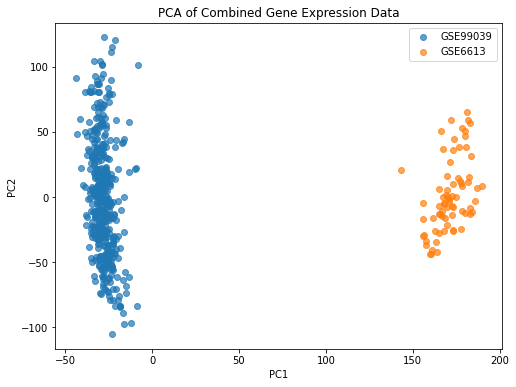

In [62]:
import matplotlib.pyplot as plt

pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "Dataset": dataset_labels
})

plt.figure(figsize=(8,6))

for dataset in pca_df["Dataset"].unique():

    subset = pca_df[
        pca_df["Dataset"] == dataset
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=dataset,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Combined Gene Expression Data")
plt.legend()
plt.show()

## PCA Reveals Strong Dataset-Level Separation

Principal Component Analysis revealed a clear separation between GSE99039 and GSE6613 along the first principal component.

The first principal component explained approximately 36.7% of the total variance, while the second explained approximately 14.0%.

Samples clustered primarily according to dataset rather than disease status, indicating substantial transcriptomic differences between cohorts.

This observation is consistent with the poor external validation performance observed for both probe-level and gene-level harmonization approaches.

The PCA results suggest that technical and cohort-specific effects may dominate the biological signal associated with Parkinson's disease, limiting cross-study generalization.

---

# Batch Effect Correction Using ComBat

PCA revealed strong dataset-level separation between GSE99039 and GSE6613, suggesting that technical or cohort-specific batch effects may dominate the biological disease signal.

To investigate whether harmonization can reduce these dataset-level differences, ComBat batch correction is applied to the combined gene-level expression matrix.

In this analysis:

- GSE99039 and GSE6613 are treated as separate batches
- Correction is performed on the shared gene-level feature space
- Disease labels are not used during batch correction
- The corrected data are later re-evaluated using PCA and external validation

This step is exploratory and is used to assess whether batch correction can improve cross-cohort alignment and model generalization.

In [63]:
!pip install neuroCombat

In [64]:
from neuroCombat import neuroCombat
import pandas as pd

# Combine gene-level expression matrices
combined_X = pd.concat(
    [gse99039_genes_common, gse6613_genes_common],
    axis=0
)

# Metadata describing batch membership
combat_metadata = pd.DataFrame({
    "batch": (
        ["GSE99039"] * len(gse99039_genes_common)
        + ["GSE6613"] * len(gse6613_genes_common)
    )
}, index=combined_X.index)

# neuroCombat expects features × samples
combat_result = neuroCombat(
    dat=combined_X.T,
    covars=combat_metadata,
    batch_col="batch"
)

combined_combat = pd.DataFrame(
    combat_result["data"].T,
    index=combined_X.index,
    columns=combined_X.columns
)

print(combined_combat.shape)

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
(510, 13237)


In [65]:
gse99039_combat = combined_combat.loc[gse99039_genes_common.index]
gse6613_combat = combined_combat.loc[gse6613_genes_common.index]

print(gse99039_combat.shape)
print(gse6613_combat.shape)

(438, 13237)
(72, 13237)


## PCA After ComBat Batch Correction

To evaluate whether ComBat successfully reduced dataset-level batch effects, Principal Component Analysis (PCA) is repeated on the corrected gene expression matrix.

If batch correction is effective, samples from GSE99039 and GSE6613 should become more intermixed in PCA space, indicating improved alignment between cohorts.

The corrected PCA visualization provides a qualitative assessment of whether dataset-specific variation has been reduced.

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

combined_combat_scaled = StandardScaler().fit_transform(
    combined_combat
)

pca = PCA(n_components=2)

pca_result_combat = pca.fit_transform(
    combined_combat_scaled
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Explained variance: [0.28094252 0.07167133]


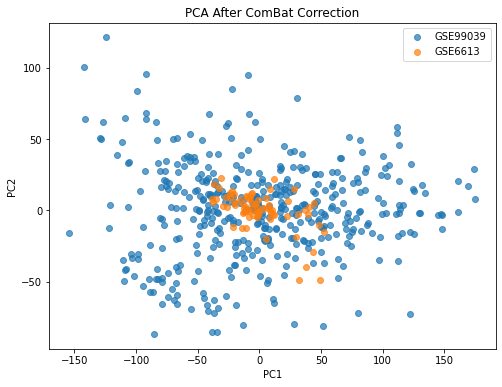

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

pca_combat_df = pd.DataFrame({
    "PC1": pca_result_combat[:, 0],
    "PC2": pca_result_combat[:, 1],
    "Dataset": dataset_labels
})

plt.figure(figsize=(8,6))

for dataset in pca_combat_df["Dataset"].unique():

    subset = pca_combat_df[
        pca_combat_df["Dataset"] == dataset
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=dataset,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA After ComBat Correction")
plt.legend()
plt.show()

## External Validation After ComBat Correction

Following batch correction, the classifier is retrained using the corrected GSE99039 training cohort and evaluated on the corrected GSE6613 external validation cohort.

This analysis assesses whether reducing dataset-level batch effects improves cross-cohort generalization performance.

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)

X_train = gse99039_combat
y_train = gse99039_y

X_external = gse6613_combat
y_external = gse6613_y

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_external_scaled = scaler.transform(X_external)

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_proba = model.predict_proba(
    X_external_scaled
)[:, 1]

y_pred = model.predict(
    X_external_scaled
)

print(
    "External ROC-AUC:",
    roc_auc_score(
        y_external,
        y_proba
    )
)

print()
print(confusion_matrix(
    y_external,
    y_pred
))

print()
print(classification_report(
    y_external,
    y_pred,
    digits=3,
    zero_division=0
))

External ROC-AUC: 0.5772727272727273

[[15  7]
 [27 23]]

              precision    recall  f1-score   support

           0      0.357     0.682     0.469        22
           1      0.767     0.460     0.575        50

    accuracy                          0.528        72
   macro avg      0.562     0.571     0.522        72
weighted avg      0.642     0.528     0.543        72



## Summary of Validation Results

| Feature Representation | Internal ROC-AUC (5-fold CV) | External ROC-AUC (GSE6613) |
|------------------------|-----------------------------:|---------------------------:|
| Full GPL570 probes (54,675) | ~0.71 | — |
| Common probes (22,277) | 0.617 | 0.460 |
| Common genes (13,237) | 0.622 | 0.498 |
| Common genes + ComBat | — | **0.577** |

### Key Observations

- The original GSE99039 model achieved moderate predictive performance during internal validation (ROC-AUC ≈ 0.71).
- Restricting the analysis to features shared across platforms reduced internal performance (ROC-AUC ≈ 0.62).
- External validation initially failed, with performance close to random classification (ROC-AUC ≈ 0.50).
- PCA revealed strong dataset-level separation between GSE99039 and GSE6613, suggesting substantial batch effects.
- ComBat batch correction reduced dataset-level separation and improved external validation performance from approximately 0.50 to 0.58 ROC-AUC.
- Despite this improvement, external performance remained below internal validation performance, indicating that additional biological and cohort-specific differences likely remain.

## External Validation Progression

| Step | External ROC-AUC |
|--------|----------------:|
| Common probes | 0.460 |
| Gene-level harmonization | 0.498 |
| Gene-level harmonization + ComBat | **0.577** |

**Improvement after ComBat:** +0.079 ROC-AUC

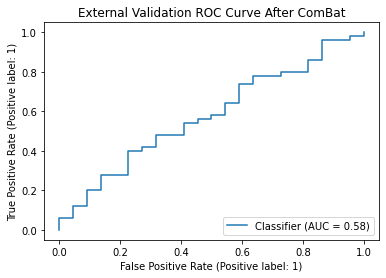

In [69]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_external,
    y_proba
)

plt.title("External Validation ROC Curve After ComBat")
plt.show()

## Summary of Batch Correction Results

External validation demonstrated that the transcriptomic classifier trained on GSE99039 does not directly generalize to GSE6613 under naive probe-level or gene-level harmonization.

PCA revealed strong dataset-level separation, indicating substantial batch effects between cohorts. After ComBat correction, cohort separation was reduced and external ROC-AUC improved to 0.577.

These results suggest that batch effects are a major barrier to cross-cohort transcriptomic model transfer, but correction alone is insufficient to fully recover the internal validation performance observed in GSE99039.

---

## Internal Cross-Validation on the Training Cohort

To evaluate whether the classifier captures a reproducible signal within the training cohort, we perform 5-fold stratified cross-validation on GSE99039.

This step provides an internal estimate of model performance before evaluating the model on an independent external cohort.

Unlike external validation, cross-validation only assesses performance within the same dataset and may still be affected by cohort-specific technical or biological patterns.

Therefore, internal cross-validation is interpreted as a baseline estimate rather than evidence of cross-study generalization.

In [70]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipe,
    gse99039_genes_common,
    gse99039_y,
    cv=cv,
    scoring="roc_auc"
)

print("CV ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std ROC-AUC:", scores.std())

CV ROC-AUC scores: [0.68655942 0.7389725  0.71665802 0.64050901 0.70254507]
Mean ROC-AUC: 0.6970488030504727
Std ROC-AUC: 0.03310317576157358


The resulting ROC-AUC scores are:

* Mean ROC-AUC ≈ 0.697
* Std ≈ 0.033

### Internal Cross-Validation Results

Using the shared gene-level feature space, Logistic Regression achieved a mean ROC-AUC of approximately 0.70 during 5-fold stratified cross-validation on GSE99039.

This result is close to the original internal validation performance obtained using the full probe-level dataset, suggesting that the gene-level representation preserves most of the predictive signal within the training cohort.

However, this result reflects internal performance only. It does not guarantee generalization to independent cohorts, as external validation on GSE6613 showed substantially lower performance before batch correction.

## Feature Selection as a Diagnostic Experiment

To test whether the predictive signal is concentrated in a smaller subset of genes, univariate feature selection is applied using the ANOVA F-test.

Feature selection is included inside the cross-validation pipeline to avoid data leakage.

This experiment evaluates whether selecting the top-ranked genes improves internal model performance within GSE99039.

In [71]:
from sklearn.feature_selection import SelectKBest, f_classif

pipe_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=500)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

scores_fs = cross_val_score(
    pipe_fs,
    gse99039_genes_common,
    gse99039_y,
    cv=cv,
    scoring="roc_auc"
)

print("FS ROC-AUC scores:", scores_fs)
print("Mean ROC-AUC:", scores_fs.mean())
print("Std ROC-AUC:", scores_fs.std())

FS ROC-AUC scores: [0.69953295 0.69278672 0.71821484 0.58112407 0.69034995]
Mean ROC-AUC: 0.6764017057376864
Std ROC-AUC: 0.048629707722028404


In [72]:
pipe_fs.fit(gse99039_genes_common, gse99039_y)

y_proba_fs = pipe_fs.predict_proba(gse6613_genes_common)[:, 1]
y_pred_fs = pipe_fs.predict(gse6613_genes_common)

print("External ROC-AUC:", roc_auc_score(gse6613_y, y_proba_fs))
print(confusion_matrix(gse6613_y, y_pred_fs))
print(classification_report(gse6613_y, y_pred_fs, digits=3, zero_division=0))

External ROC-AUC: 0.5890909090909091
[[ 9 13]
 [16 34]]
              precision    recall  f1-score   support

           0      0.360     0.409     0.383        22
           1      0.723     0.680     0.701        50

    accuracy                          0.597        72
   macro avg      0.542     0.545     0.542        72
weighted avg      0.612     0.597     0.604        72



### Feature Selection Results

Applying univariate feature selection reduced the internal cross-validation ROC-AUC from approximately 0.70 to 0.68.

However, external validation performance improved substantially, with ROC-AUC increasing from approximately 0.50 to 0.59.

These findings suggest that while a large number of genes contribute to predictive performance within the training cohort, a smaller subset of highly informative genes may provide better cross-cohort generalization.

The improvement in external performance indicates that feature selection may reduce cohort-specific noise and improve the robustness of the transcriptomic signature across independent datasets.

## Feature Selection After Batch Correction

To investigate whether feature selection can further improve generalization after batch correction, univariate ANOVA-based feature selection is applied to the ComBat-corrected gene expression data.

Feature selection is performed using only the training cohort and is incorporated within a machine learning pipeline to avoid data leakage.

This experiment evaluates whether reducing the feature space after batch correction improves external validation performance.

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe_combat_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(
        score_func=f_classif,
        k=500
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

scores = cross_val_score(
    pipe_combat_fs,
    gse99039_combat,
    gse99039_y,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print("Mean ROC-AUC:", scores.mean())
print("Std ROC-AUC:", scores.std())

[0.69953295 0.69330566 0.71821484 0.58112407 0.69034995]
Mean ROC-AUC: 0.6765054940096117
Std ROC-AUC: 0.0486651076723981


In [74]:
pipe_combat_fs.fit(
    gse99039_combat,
    gse99039_y
)

y_proba = pipe_combat_fs.predict_proba(
    gse6613_combat
)[:, 1]

y_pred = pipe_combat_fs.predict(
    gse6613_combat
)

print(
    "External ROC-AUC:",
    roc_auc_score(
        gse6613_y,
        y_proba
    )
)

print()
print(confusion_matrix(
    gse6613_y,
    y_pred
))

print()
print(classification_report(
    gse6613_y,
    y_pred,
    digits=3,
    zero_division=0
))

External ROC-AUC: 0.6336363636363637

[[16  6]
 [21 29]]

              precision    recall  f1-score   support

           0      0.432     0.727     0.542        22
           1      0.829     0.580     0.682        50

    accuracy                          0.625        72
   macro avg      0.631     0.654     0.612        72
weighted avg      0.708     0.625     0.640        72



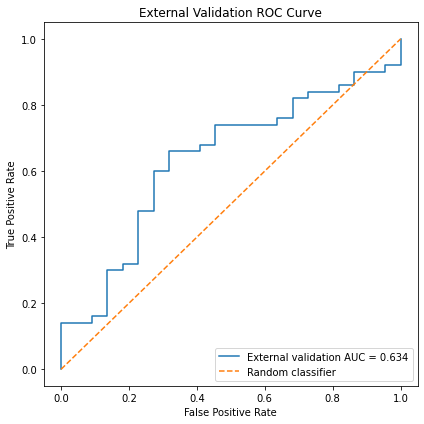

In [76]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve for the final external validation model
fpr, tpr, thresholds = roc_curve(gse6613_y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    label=f"External validation AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Combined Impact of Batch Correction and Feature Selection

The combination of ComBat batch correction and ANOVA-based feature selection produced the strongest external validation performance observed in this study.

While internal cross-validation performance decreased slightly compared to the full shared gene set, external ROC-AUC improved substantially:

- Shared genes only: ROC-AUC ≈ 0.50
- Shared genes + ComBat: ROC-AUC ≈ 0.58
- Shared genes + Feature Selection: ROC-AUC ≈ 0.59
- Shared genes + ComBat + Feature Selection: ROC-AUC ≈ 0.63

These results suggest that reducing batch effects and restricting the model to a smaller set of highly informative genes improves cross-cohort generalization.

Importantly, the best-performing external model was not the model with the highest internal cross-validation performance, highlighting the importance of independent validation when developing transcriptomic classifiers.

### Summary of Model Performance

| Pipeline                                | External ROC-AUC |
| --------------------------------------- | ---------------: |
| Probe-level harmonization               |             0.46 |
| Gene-level harmonization                |             0.50 |
| Gene-level + ComBat                     |             0.58 |
| Gene-level + Feature Selection          |             0.59 |
| Gene-level + ComBat + Feature Selection |         **0.63** |

---

## Model Comparison After Harmonization and Batch Correction

After identifying ComBat correction and feature selection as important steps for improving external validation, multiple classifiers are compared using the same corrected gene-level feature space.

All models are trained on the ComBat-corrected GSE99039 cohort and evaluated on the ComBat-corrected GSE6613 external validation cohort.

Feature selection is performed using only the training cohort to avoid data leakage.

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import pandas as pd

In [78]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "L1 Logistic Regression": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ),

    "Elastic Net Logistic Regression": LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        max_iter=5000,
        random_state=42
    ),

    "Linear SVM": SVC(
        kernel="linear",
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

In [79]:
results = []

for model_name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(
            score_func=f_classif,
            k=500
        )),
        ("model", model)
    ])

    pipe.fit(
        gse99039_combat,
        gse99039_y
    )

    y_proba = pipe.predict_proba(
        gse6613_combat
    )[:, 1]

    y_pred = pipe.predict(
        gse6613_combat
    )

    auc = roc_auc_score(
        gse6613_y,
        y_proba
    )

    results.append({
        "Model": model_name,
        "External ROC-AUC": auc
    })

    print("=" * 60)
    print(model_name)
    print("External ROC-AUC:", auc)
    print()
    print(confusion_matrix(
        gse6613_y,
        y_pred
    ))
    print()
    print(classification_report(
        gse6613_y,
        y_pred,
        digits=3,
        zero_division=0
    ))

results_df = pd.DataFrame(results).sort_values(
    by="External ROC-AUC",
    ascending=False
)

results_df

Logistic Regression
External ROC-AUC: 0.6336363636363637

[[16  6]
 [21 29]]

              precision    recall  f1-score   support

           0      0.432     0.727     0.542        22
           1      0.829     0.580     0.682        50

    accuracy                          0.625        72
   macro avg      0.631     0.654     0.612        72
weighted avg      0.708     0.625     0.640        72

L1 Logistic Regression
External ROC-AUC: 0.5645454545454546

[[12 10]
 [21 29]]

              precision    recall  f1-score   support

           0      0.364     0.545     0.436        22
           1      0.744     0.580     0.652        50

    accuracy                          0.569        72
   macro avg      0.554     0.563     0.544        72
weighted avg      0.627     0.569     0.586        72

Elastic Net Logistic Regression
External ROC-AUC: 0.5990909090909091

[[15  7]
 [22 28]]

              precision    recall  f1-score   support

           0      0.405     0.682     0.50

,Model,External ROC-AUC
0,Logistic Regression,0.633636
2,Elastic Net Logistic Regression,0.599091
4,Random Forest,0.591364
3,Linear SVM,0.576364
1,L1 Logistic Regression,0.564545


| Model | External ROC-AUC |
|---------|---------:|
| Logistic Regression | **0.634** |
| Elastic Net Logistic Regression | 0.599 |
| Random Forest | 0.591 |
| Linear SVM | 0.576 |
| L1 Logistic Regression | 0.565 |

Among the evaluated classifiers, standard Logistic Regression achieved the highest external validation performance after gene-level harmonization, ComBat correction, and feature selection.

More complex models, including Random Forest and SVM, did not improve external generalization, suggesting that the transferable disease signal is largely linear in the selected feature space.

These results indicate that preprocessing and harmonization had a larger impact on performance than classifier choice.

---

## Identification of Top-Ranked Genes

In [80]:
pipe_combat_fs.fit(
    gse99039_combat,
    gse99039_y
)

selector = pipe_combat_fs.named_steps["selector"]

selected_genes = (
    gse99039_combat.columns[
        selector.get_support()
    ]
)

print(len(selected_genes))
print(selected_genes[:20])

500
Index(['ABHD2', 'ABHD4', 'ABR', 'ACIN1', 'ACTN1', 'ACTN4', 'ACTR1A', 'ADAM8',
       'ADAMTSL4', 'ADRM1', 'AKIP1', 'AKT1', 'ALAS2', 'ALDOA', 'ALOX5',
       'ALOX5AP', 'AMPD2', 'ANAPC2', 'ANK3', 'ANO10'],
      dtype='object', name='Gene Symbol')


In [81]:
coef = (
    pipe_combat_fs
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "gene": selected_genes,
    "coefficient": coef
})

coef_df["abs_coef"] = (
    coef_df["coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "abs_coef",
    ascending=False
)

coef_df.head(20)

,gene,coefficient,abs_coef
336,PPP2R1A,0.957521,0.957521
63,CD14,0.938020,0.938020
113,DNASE2,0.882959,0.882959
185,ICAM1,-0.879771,0.879771
215,KIR2DL3,0.877196,0.877196
449,TMEM185B,-0.863464,0.863464
213,KIR2DL1,0.809459,0.809459
280,NACC2,0.794294,0.794294
86,COTL1,-0.781305,0.781305
56,CACNA1I,-0.779873,0.779873


### Biological Interpretation of Selected Genes

The final model was trained using the shared gene-level feature space after ComBat correction and ANOVA-based feature selection.

Several highly ranked genes are involved in immune regulation and inflammatory signaling, which is consistent with growing evidence implicating systemic immune dysfunction in Parkinson’s disease.

Notable examples include:

- **PTGDS**, previously reported as differentially expressed in Parkinson’s disease blood samples.
- **KIR2DL1** and **KIR2DL3**, regulators of natural killer (NK) cell activity.
- **CD14**, a marker of innate immune activation and monocyte function.
- **ICAM1**, involved in leukocyte adhesion and inflammatory responses.
- **P2RX1**, a purinergic receptor implicated in immune signaling.

Importantly, PTGDS remained among the top-ranked genes after cross-platform harmonization, batch correction, and external validation, suggesting that its association with Parkinson’s disease is relatively robust across cohorts.

## Literature Validation of Top Candidate Genes

To assess the biological plausibility of the identified biomarkers, the highest-ranked genes were compared with findings reported in the Parkinson’s disease and neuroinflammation literature.

Several top-ranked genes have previously been implicated in immune regulation, inflammatory signaling, or Parkinson’s disease pathophysiology.

| Gene | Evidence in Parkinson's Disease | Immune / Neuroinflammation Relevance | Interpretation |
|--------|--------|--------|--------|
| **PTGDS** | Reported as differentially expressed in blood-based PD studies | Indirect | One of the strongest candidates; independently identified in both the original and externally validated analyses. |
| **CD14** | Frequently associated with immune alterations in PD patients | Strong | Marker of monocytes and innate immune activation. |
| **ICAM1** | Reported among inflammatory markers in PD | Strong | Involved in leukocyte adhesion and inflammatory responses. |
| **KIR2DL1** | Limited direct PD evidence | Strong | Regulates NK-cell activity and innate immune responses. |
| **KIR2DL3** | Limited direct PD evidence | Strong | Supports the emerging role of NK cells in PD-associated immune dysregulation. |
| **KIR3DL1** | Limited direct PD evidence | Strong | Additional NK-cell receptor identified among top model features. |
| **ITGAM (CD11b)** | Frequently linked to immune activation | Strong | Classical marker of myeloid cells and inflammatory responses. |
| **PTK2B** | Implicated in neurodegenerative pathways | Moderate | Participates in signaling pathways relevant to neuronal and immune function. |
| **PSAP** | Biologically relevant to neurodegeneration | Moderate | Involved in lysosomal function, a pathway strongly implicated in PD. |
| **P2RX1** | Limited direct PD evidence | Moderate | Purinergic signaling contributes to immune activation and inflammation. |

### Comparison with the Initial Probe-Level Analysis

The initial probe-level analysis performed on GSE99039 identified several candidate biomarkers, including **PTGDS** and **KIR2DL1**. However, those findings were derived from a single cohort and were not evaluated for cross-cohort reproducibility.

After gene-level harmonization, external validation, ComBat correction, and feature selection, both PTGDS and **KIR2DL1** remained among the highest-ranked model features. In addition, related immune-associated genes such as **KIR2DL3**, **CD14**, **ICAM1**, **ITGAM**, and **SIGLEC9** emerged as important contributors to classification performance.

Compared with the original analysis, the externally validated model shows a stronger enrichment for genes involved in innate immunity, natural killer cell regulation, and inflammatory signaling. This pattern is consistent with growing evidence that immune dysregulation contributes to Parkinson’s disease pathophysiology.

Importantly, **PTGDS** remained informative throughout the entire analysis pipeline, suggesting that its association with Parkinson’s disease is relatively robust across independent cohorts and preprocessing strategies.

## Visualization of Top-Ranked Genes

To improve interpretability, the highest-ranked genes identified by the final Logistic Regression model are visualized according to the absolute magnitude of their coefficients.

The coefficient magnitude reflects the relative contribution of each gene to the classification decision after:

- gene-level harmonization,
- ComBat batch correction,
- feature selection,
- and external validation.

Genes with larger absolute coefficients exert a stronger influence on model predictions and may represent candidate transcriptomic biomarkers for Parkinson’s disease.

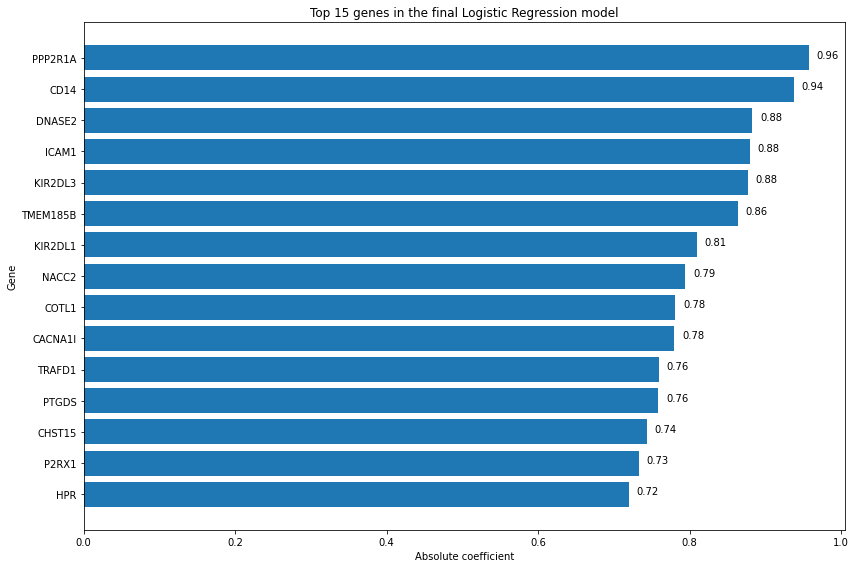

In [82]:
plot_df = (
    coef_df
    .head(15)
    .sort_values("abs_coef")
)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["gene"],
    plot_df["abs_coef"]
)

for i, value in enumerate(plot_df["abs_coef"]):
    plt.text(
        value + 0.01,   # чуть правее конца столбца
        i,              # позиция по Y
        f"{value:.2f}"  # подпись значения
    )

plt.xlabel("Absolute coefficient")
plt.ylabel("Gene")
plt.title(
    "Top 15 genes in the final Logistic Regression model"
)

plt.tight_layout()
plt.show()

---

# Conclusion

In this project, we investigated whether blood transcriptomic profiles can be used to distinguish patients with Parkinson’s disease (PD) from healthy controls across independent cohorts.

The analysis was performed using two publicly available GEO datasets:

* **GSE99039** as the training cohort (438 samples)
* **GSE6613** as an independent external validation cohort (72 samples)

Because the datasets were generated on different Affymetrix platforms, gene-level harmonization was performed using platform annotations. Probe-level expression values were mapped to gene symbols, aggregated to gene-level expression matrices, and restricted to a shared set of 13,237 genes.

Several important findings emerged from the analysis:

* Internal cross-validation on GSE99039 produced a mean ROC-AUC of approximately **0.70**, indicating the presence of a reproducible transcriptomic signal associated with Parkinson’s disease.
* Direct external validation initially failed, with performance close to random prediction (ROC-AUC ≈ **0.50**), highlighting substantial cross-study differences.
* Principal Component Analysis revealed a strong batch effect between cohorts.
* Application of **ComBat batch correction** substantially improved cohort alignment and increased external ROC-AUC.
* Additional feature selection further improved external validation performance.

The best-performing pipeline consisted of:

* gene-level harmonization,
* ComBat batch correction,
* ANOVA-based feature selection (top 500 genes),
* Logistic Regression classification.

This approach achieved an external ROC-AUC of approximately **0.63** on the independent GSE6613 cohort.

Model interpretation identified several biologically plausible candidate genes, including **PTGDS**, **CD14**, **ICAM1**, **KIR2DL1**, **KIR2DL3**, **ITGAM**, and **PTK2B**. Many of these genes are involved in immune regulation, innate immunity, and inflammatory signaling pathways.

A notable observation is that the strongest reproducible signal across cohorts appears to be associated with immune and inflammatory processes rather than a small number of neuron-specific biomarkers. This finding is consistent with growing evidence supporting a role for systemic immune dysregulation and neuroinflammation in Parkinson’s disease.

Overall, the results demonstrate both the potential and the challenges of applying machine learning to blood transcriptomic data. While predictive performance remains moderate, external validation confirms that biologically meaningful disease-related signals can be detected across independent cohorts when appropriate harmonization and batch-correction strategies are applied.

# Limitations

* Moderate sample size relative to transcriptomic dimensionality.
* Remaining biological and technical heterogeneity between cohorts.
* Only microarray datasets were analyzed.
* Feature selection was based on univariate statistical tests and may not capture complex interactions.
* External validation performance remains modest (ROC-AUC ≈ 0.63), indicating that additional improvements are needed.

# Future Work

* Evaluate additional machine learning models and hyperparameter optimization strategies.
* Perform pathway enrichment and gene set analysis.
* Validate findings on additional independent Parkinson’s disease cohorts.
* Investigate model interpretability methods such as SHAP.
* Compare microarray-based signatures with RNA-seq datasets.

This project demonstrates a complete machine learning workflow for cross-cohort transcriptomic analysis, including data harmonization, batch correction, external validation, model comparison, and biological interpretation.

## References

1. Gene Expression Omnibus (GEO).
   GSE99039: Blood-based transcriptomic profiling of Parkinson’s disease patients and healthy controls.

2. Gene Expression Omnibus (GEO).
   GSE6613: Whole blood gene expression dataset used as an independent external validation cohort.

3. Soreq, L., Bergman, H., Israel, Z., & Soreq, H. (2013).
   Major shifts in glial regional identity are a transcriptional hallmark of human brain aging. *Cell Reports*, 18(2), 557–570.

4. Singleton, A. B., Farrer, M. J., & Bonifati, V. (2013).
   The genetics of Parkinson’s disease: progress and therapeutic implications. *The Lancet Neurology*, 12(5), 500–512.

6. Leavy, O. (2014).
   Neurodegenerative diseases: Innate immunity in Parkinson disease. *Nature Reviews Immunology*, 14, 357.

7. Vivier, E., Raulet, D. H., Moretta, A., et al. (2011).
   Innate or adaptive immunity? The example of natural killer cells. *Science*, 331(6013), 44–49.

8. Abel, A., & Funk, C. D. (2016).
   Metabolism of prostaglandins and the role of prostaglandin D synthase (PTGDS) in neurological disease. *Journal of Lipid Research*.

9. Hirsch, E. C., Standaert, D. G. (2021).
   Ten unsolved questions about neuroinflammation in Parkinson’s disease. *Movement Disorders*, 36(1), 16–24.

10. Tansey, M. G., Romero-Ramos, M. (2019).
    Immune system responses in Parkinson’s disease: Early and dynamic. *European Journal of Neuroscience*, 49(3), 364–383.

11. NCBI Gene Database.
    Gene records for PTGDS, CD14, ICAM1, KIR2DL1, KIR2DL3, ITGAM, PTK2B, and PSAP.

12. UniProt Knowledgebase (UniProtKB).
    Functional annotations for genes discussed in the biological interpretation section.

## Notes

AI tools (including ChatGPT) were used during the development of this project for code assistance, debugging, and conceptual clarification.

The overall design, implementation, and interpretation of results were carried out independently.